# Curriculum Learning — Detector de Identificador para ESP32-CAM

Entrena una red depthwise separable **binaria** (¿hay o no hay identificador?) usando
Curriculum Learning de 6 fases cumulativas y la cuantiza a TFLite INT8 para correr
en el ESP32-CAM (`code-cam-id`).

- Entrada: imagen 96×96 escala de grises
- Salida: `[P(sin_id), P(con_id)]` — class 1 = identificador presente
- Destino: `code-cam-id/main/model_data.h` (cabecera C generada aquí)
- Tamaño objetivo: < 10 KB INT8 — red más ligera que Lab_3 para más FPS en ESP32-CAM


In [31]:
import os, sys
from pathlib import Path

_nvidia = Path(sys.executable).parent.parent / 'lib' / 'python3.12' / 'site-packages' / 'nvidia'
_paths  = [str(p) for p in _nvidia.glob('*/lib') if p.is_dir()]
_paths.append('/usr/lib/wsl/lib')
os.environ['LD_LIBRARY_PATH'] = ':'.join(_paths + [os.environ.get('LD_LIBRARY_PATH', '')])
print('LD_LIBRARY_PATH configurado')

LD_LIBRARY_PATH configurado


## 0. Preparación del dataset

Crea la siguiente estructura de carpetas (ya existen como marcadores):

```
Extra_1/
├── easy/       # Identificador centrado, buena iluminación, fondo limpio
├── medium/     # Ángulos leves, iluminación variable, fondo simple
├── hard/       # Oclusión parcial, desenfoque, iluminación difícil
└── other/      # Imágenes tomadas por otras personas (tiene ambas clases)
```

Cada carpeta necesita un `tags.txt` con formato `nombre_archivo,etiqueta`.
El notebook acepta etiquetas de 0 a 3 y las convierte a binario:
- `0` = Sin ID (identificador ausente)
- `1`, `2`, `3` = Con ID (cualquier variante de identificador presente)

Ejemplo `easy/tags.txt`:
```
img_001.jpg,1
img_002.jpg,2
img_003.jpg,0
```

**Guía de captura:**
- Mínimo recomendado: 80 imágenes Con ID + 80 Sin ID por dificultad
- Resolución: cualquiera ≥ 96×96 (se redimensiona automáticamente)
- Formato: JPG o PNG


## 1. Imports y configuración

In [32]:
!pip install keras tensorflow Pillow scikit-learn matplotlib seaborn


In [34]:
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

DATASET_DIR = Path('.')   # ejecutar desde Sumo_Robot/Extra_1/
CLASS_NAMES = ['Sin ID', 'Con ID']
NUM_CLASSES = 2
IMG_SIZE    = 128          # debe coincidir con ml_id.c (input uint8[96x96])
BATCH_SIZE  = 32
SEED        = 42

print(f'Keras {keras.__version__}')
print(f'TensorFlow {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

Keras 3.14.1
TensorFlow 2.21.0
GPUs: []


## 2. Carga y separación del dataset

Mismo split que Lab_3/Extra_1:
- easy/medium: 0–80% train | 80–90% val | 90–100% test
- hard: 0–70% train | 70–85% val | 85–100% test
- other: 100% test (mezcla de Sin ID y Con ID, tomadas por otras personas)

Las etiquetas del `tags.txt` (0–3) se convierten automáticamente a binario:
0 → Sin ID, ≥1 → Con ID.


In [35]:
def load_subset(difficulty: str, frac_start: float, frac_end: float) -> tuple:
    d = DATASET_DIR / difficulty
    tags_file = d / 'tags.txt'
    if not tags_file.exists():
        raise FileNotFoundError(f'No se encontró {tags_file}. Ver Sección 0.')
    entries = []
    with open(tags_file) as f:
        for line in f:
            line = line.strip()
            if line:
                fname, raw_label = line.split(',')
                label = 0 if int(raw_label.strip()) == 0 else 1   # binario
                entries.append((d / fname.strip(), label))
    rng = np.random.default_rng(seed=SEED)
    entries = [entries[i] for i in rng.permutation(len(entries))]
    n = len(entries)
    entries = entries[int(frac_start * n) : int(frac_end * n)]
    X = np.array([
        np.array(
            Image.open(p).convert('L').resize((IMG_SIZE, IMG_SIZE)),
            dtype=np.float32
        )[..., np.newaxis] / 255.0
        for p, _ in entries
    ])
    y = np.array([lbl for _, lbl in entries], dtype=np.int32)
    return X, y

def concat_splits(specs):
    parts = [load_subset(d, s, e) for d, s, e in specs]
    return np.concatenate([p[0] for p in parts]), np.concatenate([p[1] for p in parts])

X_easy_raw, y_easy_raw = load_subset('easy',   0.00, 0.80)
X_med_raw,  y_med_raw  = load_subset('medium', 0.00, 0.80)
X_hard_raw, y_hard_raw = load_subset('hard',   0.00, 0.70)

X_val, y_val = concat_splits([
    ('easy',   0.80, 0.90),
    ('medium', 0.80, 0.90),
    ('hard',   0.70, 0.85),
])

X_easy_test,  y_easy_test  = load_subset('easy',   0.90, 1.00)
X_med_test,   y_med_test   = load_subset('medium', 0.90, 1.00)
X_hard_test,  y_hard_test  = load_subset('hard',   0.85, 1.00)
X_other_test, y_other_test = load_subset('other',  0.00, 1.00)

X_test = np.concatenate([X_easy_test, X_med_test, X_hard_test, X_other_test])
y_test = np.concatenate([y_easy_test, y_med_test, y_hard_test, y_other_test])

print(f'Train raw — easy: {len(X_easy_raw)}, medium: {len(X_med_raw)}, hard: {len(X_hard_raw)}')
print(f'Val: {len(X_val)}')
print(f'Test: {len(X_test)}  (easy={len(X_easy_test)}, medium={len(X_med_test)}, '
      f'hard={len(X_hard_test)}, other={len(X_other_test)})')
print(f'Distribución val   — Sin ID: {(y_val==0).sum()}, Con ID: {(y_val==1).sum()}')
print(f'Distribución test  — Sin ID: {(y_test==0).sum()}, Con ID: {(y_test==1).sum()}')


Train raw — easy: 144, medium: 180, hard: 364
Val: 119
Test: 204  (easy=19, medium=23, hard=79, other=83)
Distribución val   — Sin ID: 55, Con ID: 64
Distribución test  — Sin ID: 93, Con ID: 111


## 3. Balance y fases del curriculum

`TARGET` = imágenes por clase por dificultad después del balance.
Se eligió 100 porque `easy/` solo tiene **56 Sin ID** (clase minoritaria);
con TARGET=100 el oversampling es ×1.8, aceptable con augmentación.
Subirlo a 150 genera oversampling ×2.7 que perjudica la generalización.


In [36]:
def balance_dataset(X, y, target_per_class=100, seed=SEED):
    rng = np.random.default_rng(seed)
    X_out, y_out = [], []
    for c in range(NUM_CLASSES):
        mask = y == c
        X_c = X[mask]
        if len(X_c) == 0:
            raise ValueError(f'Clase {CLASS_NAMES[c]} sin muestras en este subset.')
        idx = rng.choice(len(X_c), target_per_class, replace=(len(X_c) < target_per_class))
        X_out.append(X_c[idx])
        y_out.append(np.full(target_per_class, c, dtype=np.int32))
    X_out, y_out = np.concatenate(X_out), np.concatenate(y_out)
    perm = rng.permutation(len(X_out))
    return X_out[perm], y_out[perm]

TARGET = 100          # imágenes por clase por dificultad
X_easy_b, y_easy_b = balance_dataset(X_easy_raw, y_easy_raw, target_per_class=TARGET)
X_med_b,  y_med_b  = balance_dataset(X_med_raw,  y_med_raw,  target_per_class=TARGET)
X_hard_b, y_hard_b = balance_dataset(X_hard_raw, y_hard_raw, target_per_class=TARGET)

n = TARGET * NUM_CLASSES  # 200

# 6 fases cumulativas: fácil → medio → difícil (primera mitad), luego segunda mitad
ph1_X, ph1_y = X_easy_b[:n//2],      y_easy_b[:n//2]
ph2_X, ph2_y = X_med_b[:int(n*.7)],  y_med_b[:int(n*.7)]
ph3_X, ph3_y = X_hard_b[:int(n*.3)], y_hard_b[:int(n*.3)]
ph4_X, ph4_y = X_easy_b[n//2:],      y_easy_b[n//2:]
ph5_X, ph5_y = X_med_b[int(n*.7):],  y_med_b[int(n*.7):]
ph6_X, ph6_y = X_hard_b[int(n*.3):], y_hard_b[int(n*.3):]

cum1_X, cum1_y = ph1_X, ph1_y
cum2_X = np.concatenate([cum1_X, ph2_X]); cum2_y = np.concatenate([cum1_y, ph2_y])
cum3_X = np.concatenate([cum2_X, ph3_X]); cum3_y = np.concatenate([cum2_y, ph3_y])
cum4_X = np.concatenate([cum3_X, ph4_X]); cum4_y = np.concatenate([cum3_y, ph4_y])
cum5_X = np.concatenate([cum4_X, ph5_X]); cum5_y = np.concatenate([cum4_y, ph5_y])
cum6_X = np.concatenate([cum5_X, ph6_X]); cum6_y = np.concatenate([cum5_y, ph6_y])

print(f'Balance: {TARGET}/clase = {n} imgs/dificultad')
for i, (X_p, y_p) in enumerate([
    (cum1_X,cum1_y),(cum2_X,cum2_y),(cum3_X,cum3_y),
    (cum4_X,cum4_y),(cum5_X,cum5_y),(cum6_X,cum6_y)], 1):
    sin_id = (y_p==0).sum(); con_id = (y_p==1).sum()
    print(f'  F{i}: {len(X_p):>5} imgs  ({len(X_p)//BATCH_SIZE} batches/epoch) '
          f'[Sin ID={sin_id}, Con ID={con_id}]')


Balance: 100/clase = 200 imgs/dificultad
  F1:   100 imgs  (3 batches/epoch) [Sin ID=50, Con ID=50]
  F2:   240 imgs  (7 batches/epoch) [Sin ID=120, Con ID=120]
  F3:   300 imgs  (9 batches/epoch) [Sin ID=145, Con ID=155]
  F4:   400 imgs  (12 batches/epoch) [Sin ID=195, Con ID=205]
  F5:   460 imgs  (14 batches/epoch) [Sin ID=225, Con ID=235]
  F6:   600 imgs  (18 batches/epoch) [Sin ID=300, Con ID=300]


## 4. Pipeline tf.data

In [37]:
AUTOTUNE = tf.data.AUTOTUNE

@tf.function
def augment(x, y):
    crop = tf.random.uniform((), minval=int(0.82 * IMG_SIZE), maxval=IMG_SIZE, dtype=tf.int32)
    x = tf.image.random_crop(x, [crop, crop, 1])
    x = tf.image.resize(x, [IMG_SIZE, IMG_SIZE])
    x = tf.image.random_brightness(x, max_delta=0.15)
    x = tf.image.random_contrast(x, lower=0.75, upper=1.25)
    x = tf.image.random_flip_left_right(x)   # el identificador puede venir de cualquier lado
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x, y

def make_ds(X, y, shuffle=False, aug=False):
    ds = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y))
    if shuffle:
        ds = ds.shuffle(len(X), seed=SEED)
    if aug:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds        = make_ds(X_val,        y_val)
test_ds       = make_ds(X_test,       y_test)
easy_test_ds  = make_ds(X_easy_test,  y_easy_test)
med_test_ds   = make_ds(X_med_test,   y_med_test)
hard_test_ds  = make_ds(X_hard_test,  y_hard_test)
other_test_ds = make_ds(X_other_test, y_other_test)

print('Datasets listos')

Datasets listos


## 5. Arquitectura

24→48 canales (medio camino entre el modelo demasiado pequeño de 16→32 y el
Lab_3 de 32→64). Con entrada 96×96 y salida binaria esto da ~5 200 params
y un TFLite INT8 estimado de **~15 KB**, frente a los 22.8 KB del Lab_3.

La salida es `softmax` de 2 clases; en `ml_id.c` se lee `output[1]`
(probabilidad de "Con ID") y se compara con el umbral 0.5.


In [38]:
def build_model(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    # Stem: 128 → 32 → 16
    x = layers.Conv2D(24, 5, strides=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D()(x)

    # DS block 1: 16 → 6 → 3
    x = layers.DepthwiseConv2D(3, strides=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(48, 1, use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D()(x)

    # DS block 2: 3 × 3
    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(48, 1, use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='id_detector')

model = build_model()
model.summary()
print(f'\nParámetros: {model.count_params():,}')
print(f'Tamaño float32: ~{model.count_params() * 4 / 1024:.1f} KB')
print(f'Tamaño INT8 estimado: ~{model.count_params() / 1024:.1f} KB')
print(f'Lab_3 curriculum: 9 860 params / 22.8 KB INT8 — este modelo es más ligero.')


Model: "id_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 43, 43, 24)     │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 43, 43, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 43, 43, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 21, 21, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_4              │ (None, 7, 7, 24)       │           216 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 7, 7, 24)       │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 7, 7, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 48)       │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 7, 7, 48)       │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 7, 7, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_5              │ (None, 3, 3, 48)       │           432 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 3, 3, 48)       │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 3, 3, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 48)       │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 3, 3, 48)       │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 3, 3, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 48)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            9

 Total params: 5,570 (21.76 KB)

 Trainable params: 5,186 (20.26 KB)

 Non-trainable params: 384 (1.50 KB)


Parámetros: 5,570
Tamaño float32: ~21.8 KB
Tamaño INT8 estimado: ~5.4 KB
Lab_3 curriculum: 9 860 params / 22.8 KB INT8 — este modelo es más ligero.


## 6. Entrenamiento — Curriculum Learning (6 fases cumulativas)

- **LR se resetea** al inicio de cada fase: al agregar datos más difíciles el modelo
  necesita capacidad de adaptación.
- **Checkpoint por `val_loss`** (no `val_accuracy`): evita el sesgo de un val set
  con distribución diferente al train.
- **ReduceLROnPlateau** dentro de cada fase.

In [39]:
model.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

rlr  = keras.callbacks.ReduceLROnPlateau(
    factor=0.5, patience=12, min_lr=1e-6, monitor='val_loss', verbose=1)
ckpt = keras.callbacks.ModelCheckpoint(
    'id_best.weights.h5', save_best_only=True,
    monitor='val_loss', mode='min', verbose=1, save_weights_only=True)
es   = keras.callbacks.EarlyStopping(
    patience=25, restore_best_weights=False, monitor='val_loss', verbose=1)

LR_PHASE = 5e-4
EPH = 100

phases_data = [
    (cum1_X, cum1_y, 'F1: easy[0-50%]'),
    (cum2_X, cum2_y, 'F2: +medium[0-70%]'),
    (cum3_X, cum3_y, 'F3: +hard[0-30%]'),
    (cum4_X, cum4_y, 'F4: +easy[50-100%]'),
    (cum5_X, cum5_y, 'F5: +medium[70-100%]'),
    (cum6_X, cum6_y, 'F6: +hard[30-100%]'),
]

histories = []
for X_p, y_p, name in phases_data:
    model.optimizer.learning_rate.assign(LR_PHASE)
    print(f'\n=== {name} ({len(X_p)} imgs, {len(X_p)//BATCH_SIZE} bat/ep, LR={LR_PHASE}) ===')
    h = model.fit(
        make_ds(X_p, y_p, shuffle=True, aug=True),
        epochs=EPH, validation_data=val_ds,
        callbacks=[rlr, ckpt, es],
    )
    histories.append(h)
    acc_val = float(np.mean(np.argmax(model.predict(X_val, verbose=0), axis=1) == y_val))
    print(f'  Val accuracy al terminar {name}: {acc_val*100:.1f}%')



=== F1: easy[0-50%] (100 imgs, 3 bat/ep, LR=0.0005) ===
Epoch 1/100
1/4 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.6250 - loss: 0.7889
Epoch 1: val_loss improved from None to 0.69846, saving model to id_best.weights.h5

Epoch 1: finished saving model to id_best.weights.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.4900 - loss: 0.7894 - val_accuracy: 0.4622 - val_loss: 0.6985 - learning_rate: 5.0000e-04
Epoch 2/100
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5625 - loss: 0.7016
Epoch 2: val_loss did not improve from 0.69846
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5800 - loss: 0.6731 - val_accuracy: 0.4622 - val_loss: 0.7106 - learning_rate: 5.0000e-04
Epoch 3/100
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5938 - loss: 0.5642
Epoch 3: val_loss did not improve from 0.69846
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5700 - loss: 0.6269 - val_accuracy: 0.4622 - val_loss: 0.7275 - learning_rate: 5.0000e-04
Epoch 4/100
1/4 ━━━━━━━━━━━━━━━━━━━

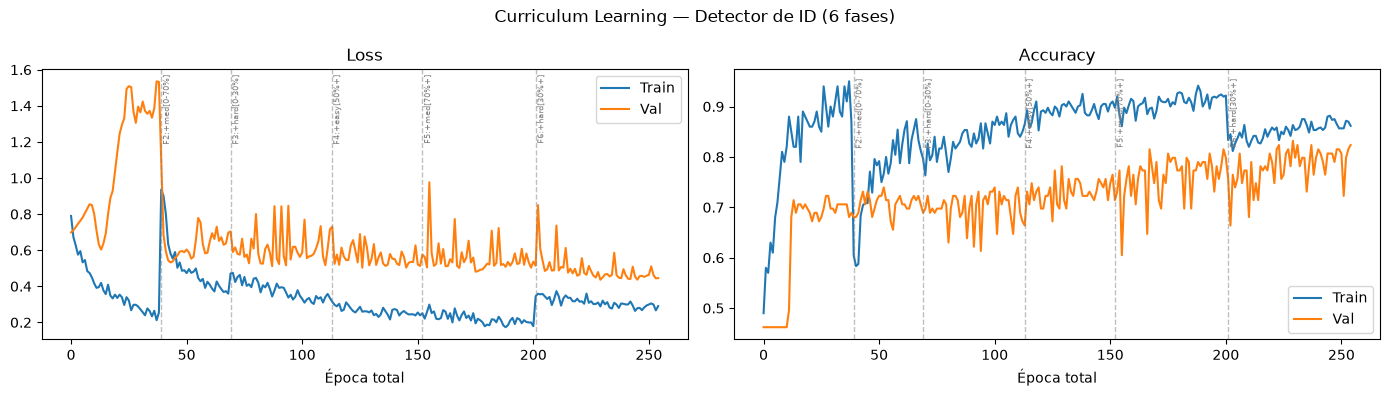

In [40]:
def cat(key, hists):
    return [v for h in hists for v in h.history[key]]

phase_labels = ['F1:easy[0-50%]', 'F2:+med[0-70%]', 'F3:+hard[0-30%]',
                'F4:+easy[50%+]',  'F5:+med[70%+]',  'F6:+hard[30%+]']
boundaries   = list(np.cumsum([len(h.history['loss']) for h in histories[:-1]]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
for ax, key, title in [(ax1, 'loss', 'Loss'), (ax2, 'accuracy', 'Accuracy')]:
    ax.plot(cat(key, histories),          label='Train')
    ax.plot(cat(f'val_{key}', histories), label='Val')
    for b, label in zip(boundaries, phase_labels[1:]):
        ax.axvline(b, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.text(b + 0.3, ax.get_ylim()[1] * 0.98, label,
                fontsize=6, rotation=90, va='top', color='gray')
    ax.set_title(title); ax.set_xlabel('Época total'); ax.legend()
plt.suptitle('Curriculum Learning — Detector de ID (6 fases)')
plt.tight_layout(); plt.show()

## 7. Benchmarking

In [41]:
model.load_weights('id_best.weights.h5')
print('Mejor modelo cargado\n')

print('=== Accuracy por dificultad ===')
for name, ds, y_d in [
    ('easy',   easy_test_ds,  y_easy_test),
    ('medium', med_test_ds,   y_med_test),
    ('hard',   hard_test_ds,  y_hard_test),
    ('other',  other_test_ds, y_other_test),
    ('TOTAL',  test_ds,       y_test),
]:
    _, acc = model.evaluate(ds, verbose=0)
    bar = chr(9608) * int(acc * 20)
    print(f'  {name:<8} {acc*100:>5.1f}%  {bar:<20}  (n={len(y_d)})')

Mejor modelo cargado

=== Accuracy por dificultad ===
  easy     100.0%  ████████████████████  (n=19)
  medium   100.0%  ████████████████████  (n=23)
  hard      70.9%  ██████████████        (n=79)
  other     68.7%  █████████████         (n=83)
  TOTAL     76.0%  ███████████████       (n=204)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


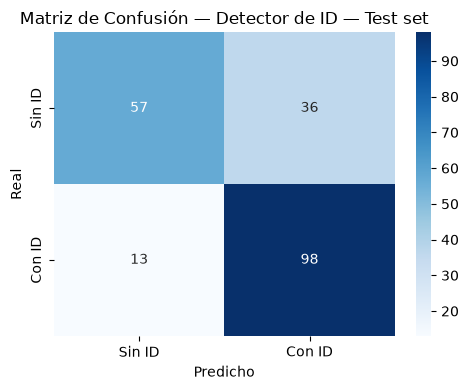

              precision    recall  f1-score   support

      Sin ID       0.81      0.61      0.70        93
      Con ID       0.73      0.88      0.80       111

    accuracy                           0.76       204
   macro avg       0.77      0.75      0.75       204
weighted avg       0.77      0.76      0.75       204

Recall    (detectar cuando hay ID): 88.3%  — quieres > 85%
Precision (evitar falsos positivos): 73.1%


In [42]:
y_pred = np.argmax(model.predict(test_ds), axis=1)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Detector de ID — Test set')
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# Métricas clave para aplicación de sumo:
tp = cm[1,1]; fn = cm[1,0]; fp = cm[0,1]; tn = cm[0,0]
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
print(f'Recall    (detectar cuando hay ID): {recall*100:.1f}%  — quieres > 85%')
print(f'Precision (evitar falsos positivos): {precision*100:.1f}%')

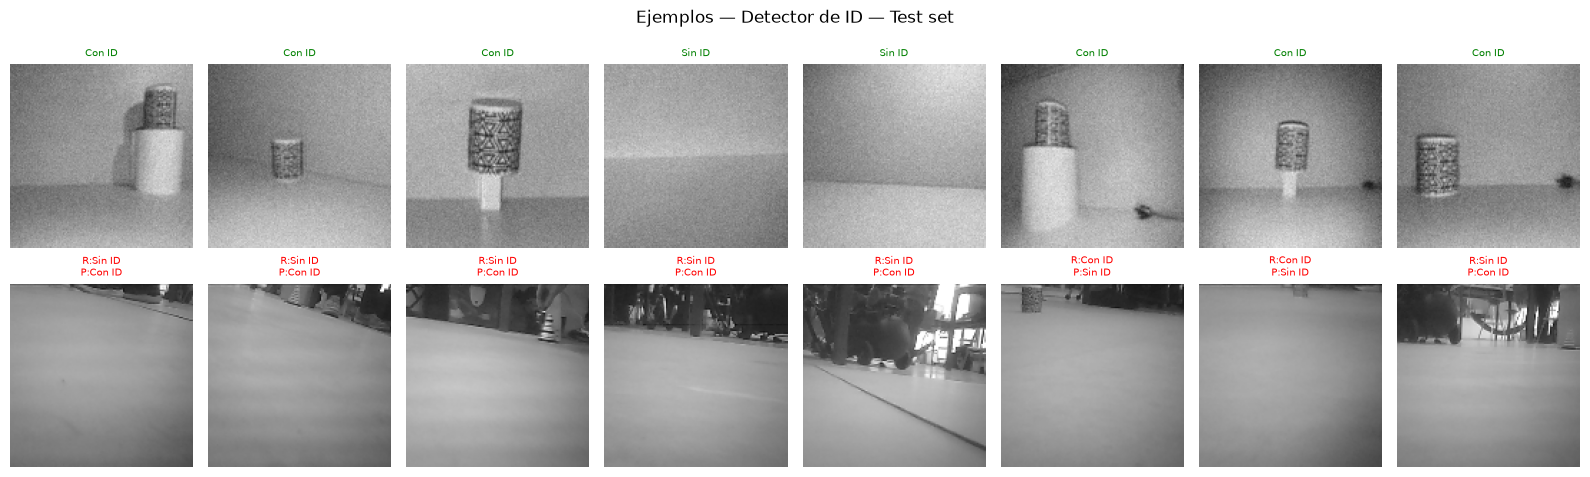

In [44]:
n_show = 8
correct_idx   = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]

fig, axes = plt.subplots(2, n_show, figsize=(16, 5))
for row, (idxs, row_label, color) in enumerate([
    (correct_idx,   'Correctas',   'green'),
    (incorrect_idx, 'Incorrectas', 'red'),
]):
    for col in range(n_show):
        ax = axes[row, col]
        if col < len(idxs):
            idx = idxs[col]
            ax.imshow(X_test[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
            real = CLASS_NAMES[y_test[idx]]
            pred = CLASS_NAMES[y_pred[idx]]
            title = real if row == 0 else f'R:{real}\nP:{pred}'
            ax.set_title(title, fontsize=7, color=color)
        ax.axis('off')
    axes[row, 0].set_ylabel(row_label, fontsize=9)
plt.suptitle('Ejemplos — Detector de ID — Test set')
plt.tight_layout(); plt.show()

## 8. Conversión a TFLite INT8

Se usa el conjunto completo (fase 6) como dataset representativo para calibrar
los rangos de cuantización. Cuanto más variado sea, mejor la precisión INT8.

In [45]:
def representative_dataset_gen():
    for i in range(0, min(200, len(cum6_X)), BATCH_SIZE):
        yield [cum6_X[i : i + BATCH_SIZE].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
Path('models/id_detector_int8.tflite').write_bytes(tflite_model)
print(f'TFLite guardado: {len(tflite_model)/1024:.1f} KB')

INFO:tensorflow:Assets written to: /tmp/tmpunaq1tom/assets


INFO:tensorflow:Assets written to: /tmp/tmpunaq1tom/assets


Saved artifact at '/tmp/tmpunaq1tom'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='keras_tensor_42')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  130410880640848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130410880640464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130410880641424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130410880641616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130410880641232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130408989362512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130408989363280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130408989363088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130408989363472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130408989361744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13040898936

/home/raisrb/uandes/sistemas-embebidos/Rep_SE_202601_grupo_Rodriguez_Guzman_Molfino/.venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1781670617.529621  101770 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1781670617.529686  101770 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1781670617.529806  101770 reader.cc:83] Reading SavedModel from: /tmp/tmpunaq1tom


TFLite guardado: 16.8 KB


I0000 00:00:1781670617.530962  101770 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1781670617.530983  101770 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpunaq1tom
I0000 00:00:1781670617.539480  101770 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1781670617.592381  101770 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpunaq1tom
I0000 00:00:1781670617.604208  101770 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 74412 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1781670617.822961  101770 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [46]:
# Validar pérdida de precisión por cuantización
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_det  = interpreter.get_input_details()[0]
output_det = interpreter.get_output_details()[0]
in_scale, in_zp   = input_det['quantization']
out_scale, out_zp = output_det['quantization']

y_tflite = []
for img in X_test:
    img_q = (img / in_scale + in_zp).astype(np.int8)
    interpreter.set_tensor(input_det['index'], img_q[np.newaxis])
    interpreter.invoke()
    raw = interpreter.get_tensor(output_det['index'])[0]    # int8[2]
    y_tflite.append(np.argmax(raw))
y_tflite = np.array(y_tflite)

acc_float  = float(np.mean(y_pred == y_test))
acc_tflite = float(np.mean(y_tflite == y_test))
print(f'\n{"Modelo":<28} {"Accuracy":>10} {"Tamaño":>10}')
print('-' * 52)
print(f'{"float32":<28} {acc_float*100:>9.1f}%  {model.count_params()*4/1024:>8.1f} KB')
print(f'{"TFLite INT8":<28} {acc_tflite*100:>9.1f}%  {len(tflite_model)/1024:>8.1f} KB')
print(f'\nDegradación por cuantización: {(acc_float - acc_tflite)*100:.1f}%')


Modelo                         Accuracy     Tamaño
----------------------------------------------------
float32                           76.0%      21.8 KB
TFLite INT8                       75.5%      16.8 KB

Degradación por cuantización: 0.5%


/home/raisrb/uandes/sistemas-embebidos/Rep_SE_202601_grupo_Rodriguez_Guzman_Molfino/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 9. Exportar cabecera C para ESP32-CAM

Genera `model_data.h` listo para copiar a `Sumo_Robot/code-cam-id/main/`.

En `ml_id.c` se usa así:
```c
#include "model_data.h"
// Cargar modelo:
model = tflite::GetModel(id_detector_model_data);
// Inferencia: output[1] = prob de "Con ID" (int8, dequantizar con scale/zero_point)
```

In [47]:
def tflite_to_c_header(tflite_bytes, var_name='id_detector_model_data',
                       output_path='../code-cam-id/main/model_data.h'):
    n = len(tflite_bytes)
    lines = [
        '// Auto-generado por id_detector_curriculum.ipynb. No editar manualmente.',
        f'// Modelo TFLite INT8 — id_detector — {n} bytes ({n/1024:.1f} KB)',
        '#pragma once',
        '#include <stdint.h>',
        '',
        f'const uint8_t {var_name}[] = {{',
    ]
    row = []
    for i, b in enumerate(tflite_bytes):
        row.append(f'0x{b:02x}')
        if len(row) == 16 or i == n - 1:
            lines.append('  ' + ', '.join(row) + ',')
            row = []
    lines.append('};')
    lines.append(f'const unsigned int {var_name}_len = {n};')

    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    Path(output_path).write_text('\n'.join(lines) + '\n')
    print(f'Header generado: {output_path}')
    print(f'  Variable: {var_name}[{n}]  ({n/1024:.1f} KB)')
    return output_path

tflite_bytes = Path('models/id_detector_int8.tflite').read_bytes()
header_path  = tflite_to_c_header(tflite_bytes)

# Equivalente shell (si prefieres xxd):
print()
print('Equivalente con xxd:')
print('  xxd -i models/id_detector_int8.tflite > ../code-cam-id/main/model_data.h')

Header generado: ../code-cam-id/main/model_data.h
  Variable: id_detector_model_data[17240]  (16.8 KB)

Equivalente con xxd:
  xxd -i models/id_detector_int8.tflite > ../code-cam-id/main/model_data.h


## 10. Guardar modelo

In [49]:
model.save('models/id_detector_final.keras')

print('Guardados en models/:')
print('  id_detector_final.keras    — Modelo float32 para reentrenar')
print('  id_detector_int8.tflite    — Listo para ESP32-CAM')
print(f'  Parámetros: {model.count_params():,}')
print()
print('Copiado a firmware:')
print('  code-cam-id/main/model_data.h')
print()
print('Próximo paso en ml_id.c:')
print('  1. #include "model_data.h"')
print('  2. Descomentar bloque TFLite en ml_id_init() y ml_id_detect()')
print('  3. Descomentar esp-tflite-micro en idf_component.yml')
print('  4. idf.py build')

Guardados en models/:
  id_detector_final.keras    — Modelo float32 para reentrenar
  id_detector_int8.tflite    — Listo para ESP32-CAM
  Parámetros: 5,570

Copiado a firmware:
  code-cam-id/main/model_data.h

Próximo paso en ml_id.c:
  1. #include "model_data.h"
  2. Descomentar bloque TFLite en ml_id_init() y ml_id_detect()
  3. Descomentar esp-tflite-micro en idf_component.yml
  4. idf.py build
